# Notebook 2 — Fusion & Data Visualisation

## Objectif
Charger et fusionner les données socio-économiques (diplômes, emploi, logement, revenus, sécurité)
avec les résultats électoraux **directement depuis DuckDB** (`warehouse.duckdb`).  
Produire des **visualisations exploratoires** pour identifier les corrélations avec le vote.

## Sources de données — toutes extraites depuis DuckDB
| Table DuckDB | Contenu | Granularité |
|---|---|---|
| `fact_candidats_blocs` | Résultats par bloc politique | Commune |
| `fact_diplomes` | Niveaux de diplôme | IRIS → agrégé par commune |
| `fact_emploi_pop_active` | Population active | Commune |
| `fact_logement` | Types de logement, HLM | IRIS → agrégé par commune |
| `fact_revenus` | Revenus, pauvreté | Commune |
| `fact_securite` | Indicateurs sécurité | Département |
| `fact_election_tour1` | Participation T1 | Bureau de vote / Commune |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Librairies chargées.')

Librairies chargées.


## 2. Extraction depuis DuckDB

Toutes les données sont extraites directement depuis `warehouse.duckdb`,
produit par l'ETL pipeline. Aucune lecture de CSV brut.

In [2]:
# ============================================================
# Connexion DuckDB et extraction de toutes les tables
# ============================================================
con = duckdb.connect('warehouse.duckdb')

df_candidats = con.execute('SELECT * FROM fact_candidats_blocs').df()
df_diplomes  = con.execute('SELECT * FROM fact_diplomes').df()
df_emploi    = con.execute('SELECT * FROM fact_emploi_pop_active').df()
df_logement  = con.execute('SELECT * FROM fact_logement').df()
df_revenus   = con.execute('SELECT * FROM fact_revenus').df()
df_securite  = con.execute('SELECT * FROM fact_securite').df()
df_t1        = con.execute('SELECT * FROM fact_election_tour1').df()

con.close()

print('Données extraites depuis DuckDB :')
print(f'  fact_candidats_blocs    : {df_candidats.shape}')
print(f'  fact_diplomes           : {df_diplomes.shape}')
print(f'  fact_emploi_pop_active  : {df_emploi.shape}')
print(f'  fact_logement           : {df_logement.shape}')
print(f'  fact_revenus            : {df_revenus.shape}')
print(f'  fact_securite           : {df_securite.shape}')
print(f'  fact_election_tour1     : {df_t1.shape}')

Données extraites depuis DuckDB :
  fact_candidats_blocs    : (267, 12)
  fact_diplomes           : (752, 17)
  fact_emploi_pop_active  : (275, 8)
  fact_logement           : (752, 23)
  fact_revenus            : (23, 12)
  fact_securite           : (180, 11)
  fact_election_tour1     : (1317, 25)


## 3. Préparation des données électorales

On part de `fact_candidats_blocs` qui contient déjà :
- Les voix et % par bloc (Gauche, Centre, Droite, Extreme_Droite)
- La variable cible `bloc_gagnant`
- La participation issue du T1

In [3]:
# ============================================================
# Base électorale : fact_candidats_blocs
# ============================================================
df_elections = df_candidats.copy()

# S'assurer que codgeo est bien formaté (5 chiffres)
df_elections['codgeo'] = df_elections['codgeo'].astype(str).str.zfill(5)

print(f'Élections : {len(df_elections)} communes')
print(f'Variable cible : {df_elections["bloc_gagnant"].value_counts().to_dict()}')

# Enrichir avec le taux de participation T1 depuis fact_election_tour1
df_part = (
    df_t1.groupby('codgeo')[['inscrits', 'abstentions', 'votants']]
    .sum()
    .reset_index()
)
df_part['taux_participation'] = (df_part['votants'] / df_part['inscrits'] * 100).round(2)
df_part['taux_abstention']    = (df_part['abstentions'] / df_part['inscrits'] * 100).round(2)
df_part['codgeo'] = df_part['codgeo'].astype(str).str.zfill(5)

df_elections = df_elections.merge(
    df_part[['codgeo', 'inscrits', 'taux_participation', 'taux_abstention']],
    on='codgeo', how='left'
)

print(f'\nAperçu :')
df_elections.head()

Élections : 267 communes
Variable cible : {'Extreme_Droite': 138, 'Centre': 100, 'Gauche': 29}

Aperçu :


,codgeo,Centre,Droite,Extreme_Droite,Gauche,bloc_gagnant,total_voix,pct_Gauche,pct_Centre,pct_Droite,pct_Extreme_Droite,annee,inscrits,taux_participation,taux_abstention
0,69001,75,17,121,37,Extreme_Droite,250,14.80,30.00,6.80,48.40,2022,316,81.01,18.99
1,69002,56,15,64,18,Extreme_Droite,153,11.76,36.60,9.80,41.83,2022,217,73.27,26.73
2,69003,501,88,421,406,Centre,1416,28.67,35.38,6.21,29.73,2022,1861,77.54,22.46
3,69004,120,25,148,96,Extreme_Droite,389,24.68,30.85,6.43,38.05,2022,470,84.47,15.53
4,69005,96,24,168,54,Extreme_Droite,342,15.79,28.07,7.02,49.12,2022,407,85.26,14.74


## 4. Préparation des features socio-économiques

In [4]:
# ============================================================
# Diplômes : agrégation IRIS → commune + calcul des ratios
# ============================================================
cols_num_dipl = ['pop_15_non_scolarise', 'sans_diplme', 'brevet',
                 'cap_bep', 'bac', 'bac_2', 'bac_3_4', 'bac_5_et']

# Agréger par commune
df_dipl_commune = df_diplomes.groupby('codgeo')[cols_num_dipl].sum().reset_index()
df_dipl_commune['codgeo'] = df_dipl_commune['codgeo'].astype(str).str.zfill(5)

# Calculer les ratios
base = df_dipl_commune['pop_15_non_scolarise'].replace(0, np.nan)
df_dipl_commune['pct_sans_diplome'] = (df_dipl_commune['sans_diplme'] / base * 100).round(2)
df_dipl_commune['pct_brevet']       = (df_dipl_commune['brevet']      / base * 100).round(2)
df_dipl_commune['pct_cap_bep']      = (df_dipl_commune['cap_bep']     / base * 100).round(2)
df_dipl_commune['pct_bac']          = (df_dipl_commune['bac']         / base * 100).round(2)
df_dipl_commune['pct_bac_plus2']    = (df_dipl_commune['bac_2']       / base * 100).round(2)
df_dipl_commune['pct_bac_plus3_4']  = (df_dipl_commune['bac_3_4']     / base * 100).round(2)
df_dipl_commune['pct_bac_plus5']    = (df_dipl_commune['bac_5_et']    / base * 100).round(2)

cols_keep = ['codgeo'] + [c for c in df_dipl_commune.columns if c.startswith('pct_')]
df_dipl_commune = df_dipl_commune[cols_keep]
print(f'Diplômes agrégés : {len(df_dipl_commune)} communes')

Diplômes agrégés : 274 communes


In [5]:
# ============================================================
# Emploi : calcul des ratios depuis fact_emploi_pop_active
# ============================================================
df_emp = df_emploi.copy()
df_emp['codgeo'] = df_emp['codgeo'].astype(str).str.zfill(5)

df_emp['pct_jeunes']   = (df_emp['pop_15_24_ans'] / df_emp['pop_15_64_ans'] * 100).round(2)
df_emp['pct_seniors']  = (df_emp['pop_55_64_ans'] / df_emp['pop_15_64_ans'] * 100).round(2)
df_emp['ratio_femmes'] = (df_emp['femmes_15_64_ans'] / df_emp['pop_15_64_ans'] * 100).round(2)

df_emp = df_emp[['codgeo', 'pop_15_64_ans', 'pct_jeunes', 'pct_seniors', 'ratio_femmes']]
print(f'Emploi : {len(df_emp)} communes')

Emploi : 275 communes


In [6]:
# ============================================================
# Logement : agrégation IRIS → commune + calcul des ratios
# ============================================================
cols_num_log = ['nb_total_de_logements', 'résidences_principales', 'résidences_secondaires',
                'logements_vacants', 'maison', 'appart', 'nb_de_ménages',
                'propriétaires', 'locataires', 'logements_sociaux_hlm',
                'ménages_avec_1_voiture', 'ménages_avec_2_voitures_ou_']

# Filtrer uniquement les colonnes existantes
cols_num_log = [c for c in cols_num_log if c in df_logement.columns]

df_log_commune = df_logement.groupby('codgeo')[cols_num_log].sum().reset_index()
df_log_commune['codgeo'] = df_log_commune['codgeo'].astype(str).str.zfill(5)

base_log = df_log_commune['nb_total_de_logements'].replace(0, np.nan)
base_rp  = df_log_commune['résidences_principales'].replace(0, np.nan)

df_log_commune['pct_proprietaires'] = (df_log_commune['propriétaires'] / base_rp * 100).round(2)
df_log_commune['pct_locataires']    = (df_log_commune['locataires']    / base_rp * 100).round(2)
df_log_commune['pct_hlm']           = (df_log_commune['logements_sociaux_hlm'] / base_rp * 100).round(2)
df_log_commune['pct_maisons']       = (df_log_commune['maison']  / base_log * 100).round(2)
df_log_commune['pct_apparts']       = (df_log_commune['appart']  / base_log * 100).round(2)
df_log_commune['pct_vacants']       = (df_log_commune['logements_vacants'] / base_log * 100).round(2)
df_log_commune['pct_2_voitures']    = (df_log_commune['ménages_avec_2_voitures_ou_'] / base_rp * 100).round(2)

cols_keep = ['codgeo'] + [c for c in df_log_commune.columns if c.startswith('pct_')]
df_log_commune = df_log_commune[cols_keep]
print(f'Logement : {len(df_log_commune)} communes')

Logement : 274 communes


In [7]:
# ============================================================
# Revenus : depuis fact_revenus
# ============================================================
df_rev = df_revenus.copy()
df_rev['codgeo'] = df_rev['codgeo'].astype(str).str.zfill(5)

# Renommer pour plus de clarté
rename_map = {}
for col in df_rev.columns:
    if 'médian' in col.lower() or 'median' in col.lower():
        rename_map[col] = 'revenu_median'
    elif 'pauvreté' in col.lower() or 'pauvrete' in col.lower():
        rename_map[col] = 'taux_pauvrete'
    elif 'inégalité' in col.lower() or 'inegalite' in col.lower():
        rename_map[col] = 'rapport_inegalite'
df_rev = df_rev.rename(columns=rename_map)

cols_rev = ['codgeo'] + [c for c in ['revenu_median', 'taux_pauvrete', 'rapport_inegalite']
                         if c in df_rev.columns]
df_rev = df_rev[cols_rev]
print(f'Revenus : {len(df_rev)} communes')
print('⚠️  Couverture partielle — imputation par médiane lors de la fusion')


# ============================================================
# Revenus : depuis fact_revenus
# ============================================================
# df_rev = df_revenus.copy()

# # Corriger un éventuel BOM sur le nom de colonne codgeo
# df_rev.columns = [c.replace('\ufeff', '') for c in df_rev.columns]

# df_rev['codgeo'] = df_rev['codgeo'].astype(str).str.zfill(5)

# # Sélection explicite des bonnes colonnes pour éviter les doublons
# cols_map = {
#     'revenu_médian_par_unité_de_consommation': 'revenu_median',
#     'taux_de_pauvreté_seuil_60': 'taux_pauvrete',
#     'rapport_dinégalité': 'rapport_inegalite'
# }

# # Garder uniquement les colonnes qui existent réellement
# cols_existantes = ['codgeo'] + [col for col in cols_map if col in df_rev.columns]
# df_rev = df_rev[cols_existantes].copy()

# # Renommer proprement
# rename_map = {col: cols_map[col] for col in cols_map if col in df_rev.columns}
# df_rev = df_rev.rename(columns=rename_map)

# # Sécurité supplémentaire : supprimer les doublons de noms de colonnes
# df_rev = df_rev.loc[:, ~df_rev.columns.duplicated()].copy()

# print(f"Revenus : {len(df_rev)} communes")
# print("Colonnes retenues :", df_rev.columns.tolist())
# print("⚠️  Couverture partielle — imputation par médiane lors de la fusion") 

Revenus : 23 communes
⚠️  Couverture partielle — imputation par médiane lors de la fusion


## 5. Fusion de toutes les sources

In [8]:
# ============================================================
# Fusion progressive sur codgeo
# ============================================================
df_final = df_elections.copy()
print(f'Base élections : {len(df_final)} communes')

df_final = df_final.merge(df_dipl_commune,  on='codgeo', how='left')
print(f'+ Diplômes     : {df_final.shape}')

df_final = df_final.merge(df_emp,           on='codgeo', how='left')
print(f'+ Emploi       : {df_final.shape}')

df_final = df_final.merge(df_log_commune,   on='codgeo', how='left')
print(f'+ Logement     : {df_final.shape}')

df_final = df_final.merge(df_rev,           on='codgeo', how='left')
print(f'+ Revenus      : {df_final.shape}')

print(f'\nDataset final : {len(df_final)} communes × {len(df_final.columns)} colonnes')

Base élections : 267 communes
+ Diplômes     : (267, 22)
+ Emploi       : (267, 26)
+ Logement     : (267, 33)
+ Revenus      : (267, 37)

Dataset final : 267 communes × 37 colonnes


In [9]:
# ============================================================
# Bilan des valeurs manquantes + imputation par médiane
# ============================================================
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final) * 100).round(1)
missing_df = pd.DataFrame({'Manquantes': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('%', ascending=False)

if len(missing_df) > 0:
    print('Colonnes avec des valeurs manquantes :')
    print(missing_df.to_string())

    # Supprimer les colonnes avec >50% de manquantes
    cols_drop = missing_df[missing_df['%'] > 50].index.tolist()
    if cols_drop:
        print(f'\nColonnes supprimées (>50%) : {cols_drop}')
        df_final = df_final.drop(columns=cols_drop)

    # Imputer par la médiane les colonnes numériques restantes
    for col in df_final.select_dtypes(include='number').columns:
        if df_final[col].isnull().sum() > 0:
            df_final[col] = df_final[col].fillna(df_final[col].median())

print(f'\nValeurs manquantes restantes : {df_final.isnull().sum().sum()}')

Colonnes avec des valeurs manquantes :
                   Manquantes     %
revenu_median             248  92.9
revenu_median             248  92.9
rapport_inegalite         248  92.9
taux_pauvrete             248  92.9
pct_sans_diplome            2   0.7
pct_brevet                  2   0.7
pct_bac_plus3_4             2   0.7
pct_bac_plus2               2   0.7
pct_bac                     2   0.7
pct_cap_bep                 2   0.7
pct_bac_plus5               2   0.7
pop_15_64_ans               2   0.7
pct_jeunes                  2   0.7
pct_seniors                 2   0.7
pct_hlm                     2   0.7
pct_locataires              2   0.7
pct_proprietaires           2   0.7
ratio_femmes                2   0.7
pct_2_voitures              2   0.7
pct_vacants                 2   0.7
pct_apparts                 2   0.7
pct_maisons                 2   0.7

Colonnes supprimées (>50%) : ['revenu_median', 'revenu_median', 'rapport_inegalite', 'taux_pauvrete']

Valeurs manquantes restantes 

## 6. Data Visualisation exploratoire

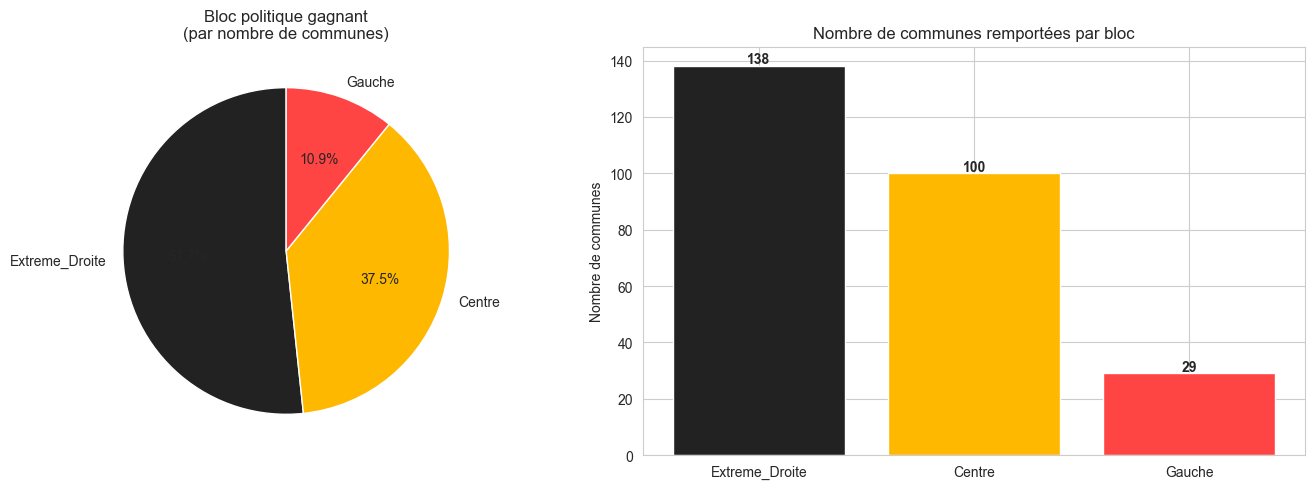

In [10]:
# ============================================================
# GRAPHIQUE 1 : Répartition du bloc gagnant par commune
# ============================================================
couleurs = {
    'Gauche':         '#FF4444',
    'Centre':         '#FFB800',
    'Droite':         '#4488FF',
    'Extreme_Droite': '#222222'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df_final['bloc_gagnant'].value_counts()
colors = [couleurs.get(b, '#999999') for b in counts.index]

axes[0].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Bloc politique gagnant\n(par nombre de communes)')

axes[1].bar(counts.index, counts.values, color=colors)
axes[1].set_ylabel('Nombre de communes')
axes[1].set_title('Nombre de communes remportées par bloc')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
# plt.savefig('graph_01_repartition_blocs.png', dpi=150, bbox_inches='tight')
plt.show()

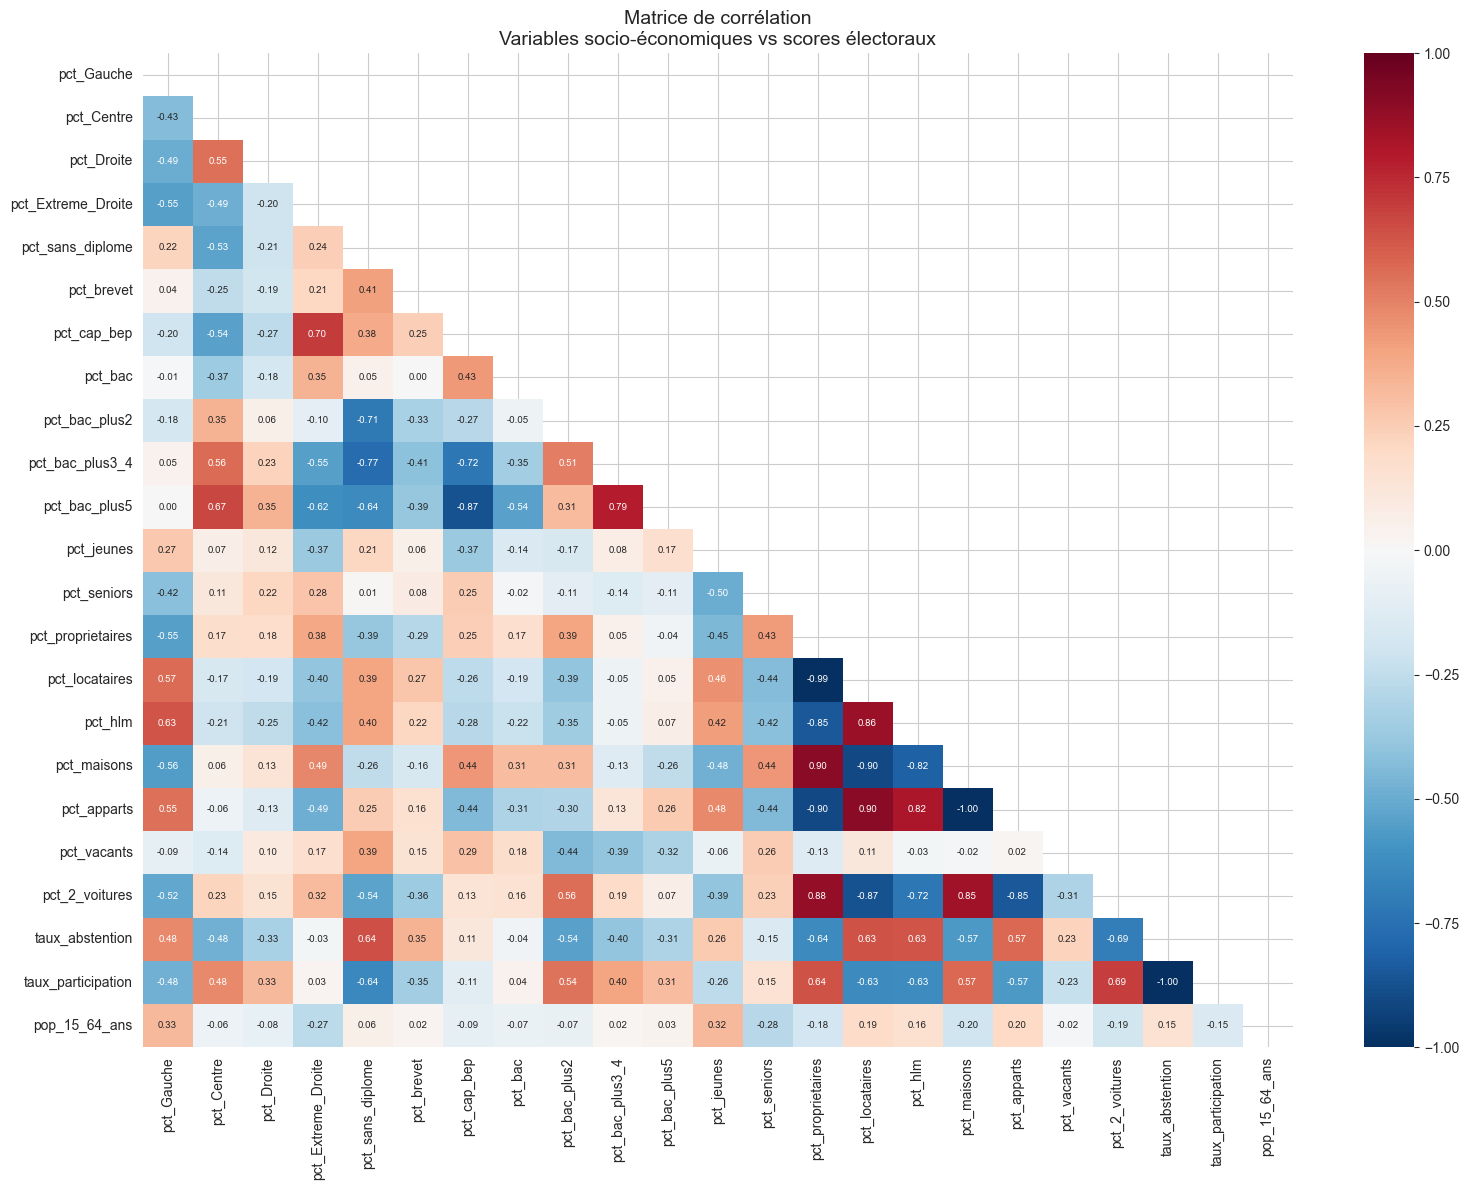

In [11]:
# ============================================================
# GRAPHIQUE 2 : Matrice de corrélation
# ============================================================
cols_pct_vote = [c for c in df_final.columns if c.startswith('pct_') and
                 any(b in c for b in ['Gauche', 'Centre', 'Droite', 'Extreme'])]
cols_socio    = [c for c in df_final.columns if c.startswith('pct_') and c not in cols_pct_vote]
cols_autres   = [c for c in ['taux_abstention', 'taux_participation', 'pop_15_64_ans',
                              'revenu_median', 'taux_pauvrete'] if c in df_final.columns]

cols_corr = cols_pct_vote + cols_socio + cols_autres
cols_corr = [c for c in cols_corr if c in df_final.columns]

corr_matrix = df_final[cols_corr].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 7})
ax.set_title('Matrice de corrélation\nVariables socio-économiques vs scores électoraux', fontsize=14)
plt.tight_layout()
# plt.savefig('graph_02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

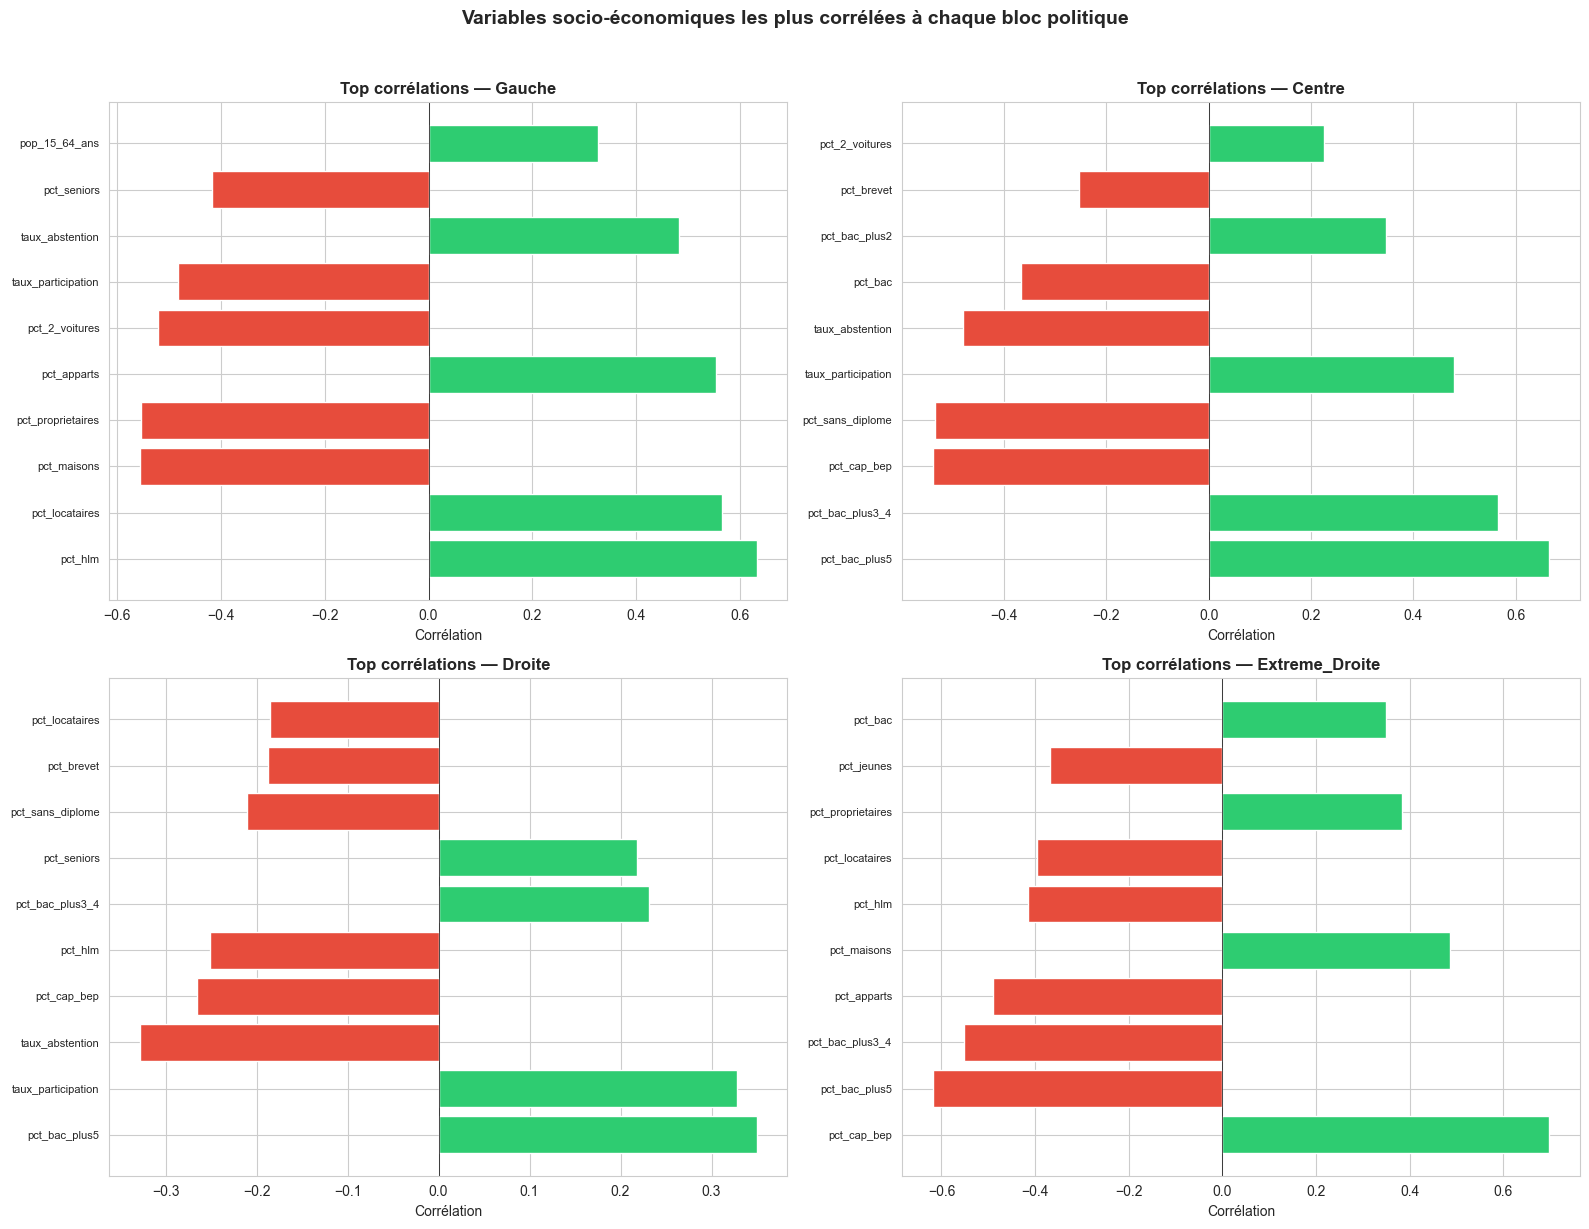

In [12]:
# ============================================================
# GRAPHIQUE 3 : Top corrélations avec chaque bloc politique
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, bloc in enumerate(['Gauche', 'Centre', 'Droite', 'Extreme_Droite']):
    col_bloc = f'pct_{bloc}'
    if col_bloc not in df_final.columns:
        continue
    correlations = df_final[cols_socio + cols_autres].corrwith(df_final[col_bloc]).dropna()
    correlations = correlations.sort_values(key=abs, ascending=False).head(10)

    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in correlations.values]
    axes[i].barh(range(len(correlations)), correlations.values, color=colors)
    axes[i].set_yticks(range(len(correlations)))
    axes[i].set_yticklabels(correlations.index, fontsize=8)
    axes[i].set_xlabel('Corrélation')
    axes[i].set_title(f'Top corrélations — {bloc}', fontweight='bold')
    axes[i].axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Variables socio-économiques les plus corrélées à chaque bloc politique',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('graph_03_top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\anask\AppData\Local\Temp\ipykernel_6104\1542052746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='bloc_gagnant', y=var,
C:\Users\anask\AppData\Local\Temp\ipykernel_6104\1542052746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='bloc_gagnant', y=var,
C:\Users\anask\AppData\Local\Temp\ipykernel_6104\1542052746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='bloc_gagnant', y=var,
C:\Users\anask\AppData\Local\Temp\ipykernel_6104\1542052746.py:15: FutureWarning: 

Pass

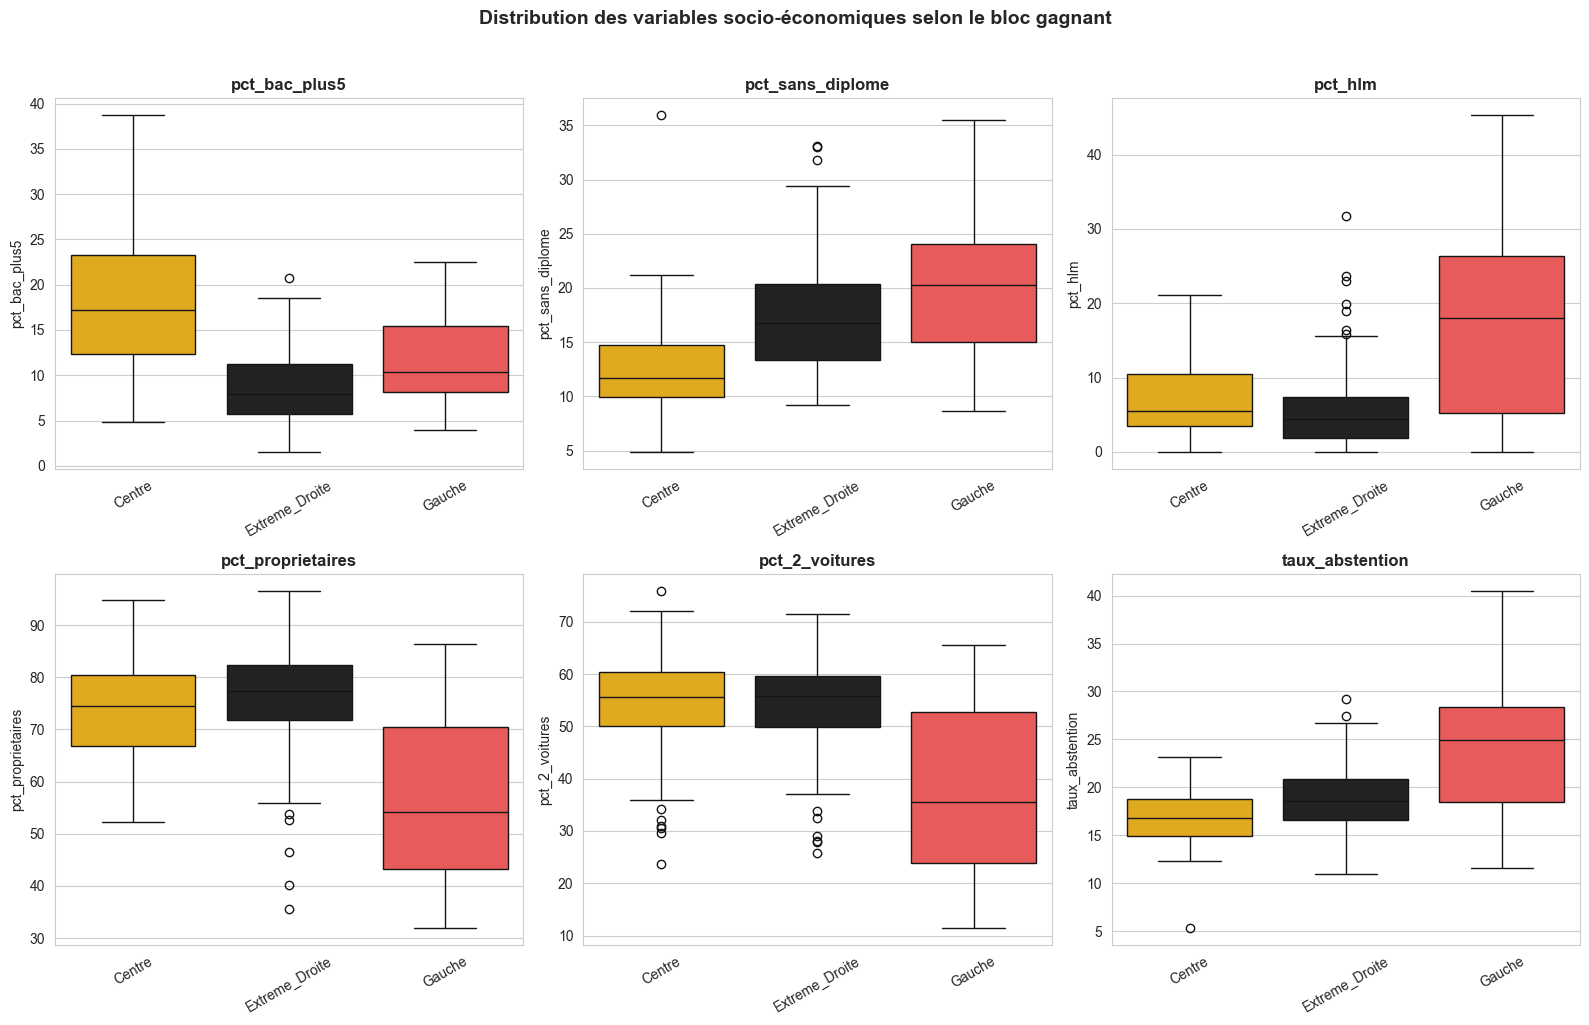

In [13]:
# ============================================================
# GRAPHIQUE 4 : Boxplots — variables clés par bloc gagnant
# ============================================================
vars_interet = [v for v in ['pct_bac_plus5', 'pct_sans_diplome', 'pct_hlm',
                             'pct_proprietaires', 'pct_2_voitures', 'taux_abstention']
                if v in df_final.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

order   = sorted(df_final['bloc_gagnant'].unique())
palette = [couleurs.get(b, '#999') for b in order]

for i, var in enumerate(vars_interet):
    sns.boxplot(data=df_final, x='bloc_gagnant', y=var,
                order=order, palette=palette, ax=axes[i])
    axes[i].set_title(var, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for i in range(len(vars_interet), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution des variables socio-économiques selon le bloc gagnant',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('graph_04_boxplots_blocs.png', dpi=150, bbox_inches='tight')
plt.show()

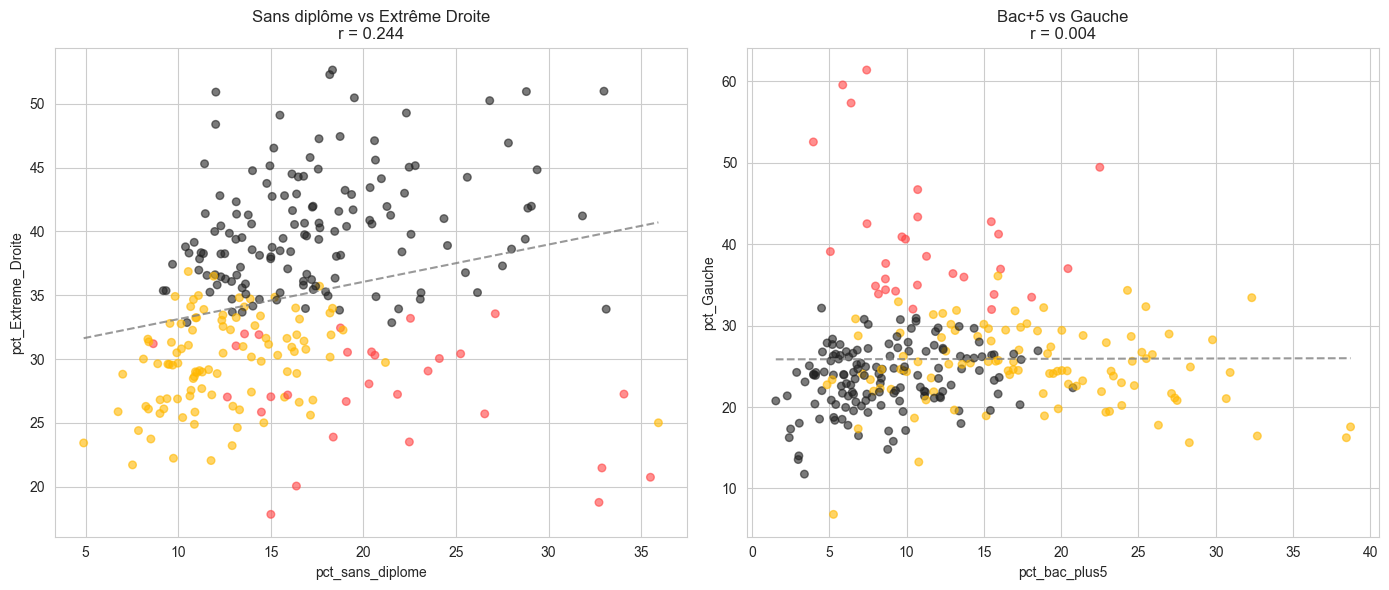

In [14]:
# ============================================================
# GRAPHIQUE 5 : Scatter plots — corrélations clés
# ============================================================
scatter_vars = [
    ('pct_sans_diplome', 'pct_Extreme_Droite', 'Sans diplôme vs Extrême Droite'),
    ('pct_bac_plus5',    'pct_Gauche',         'Bac+5 vs Gauche')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (x_var, y_var, title) in enumerate(scatter_vars):
    if x_var in df_final.columns and y_var in df_final.columns:
        colors = [couleurs.get(b, '#999') for b in df_final['bloc_gagnant']]
        axes[i].scatter(df_final[x_var], df_final[y_var], c=colors, alpha=0.6, s=30)
        z = np.polyfit(df_final[x_var].dropna(),
                       df_final.loc[df_final[x_var].notna(), y_var], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_final[x_var].min(), df_final[x_var].max(), 100)
        axes[i].plot(x_line, p(x_line), '--', color='gray', alpha=0.8)
        corr = df_final[x_var].corr(df_final[y_var])
        axes[i].set_xlabel(x_var)
        axes[i].set_ylabel(y_var)
        axes[i].set_title(f'{title}\nr = {corr:.3f}')

plt.tight_layout()
# plt.savefig('graph_05_scatter_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

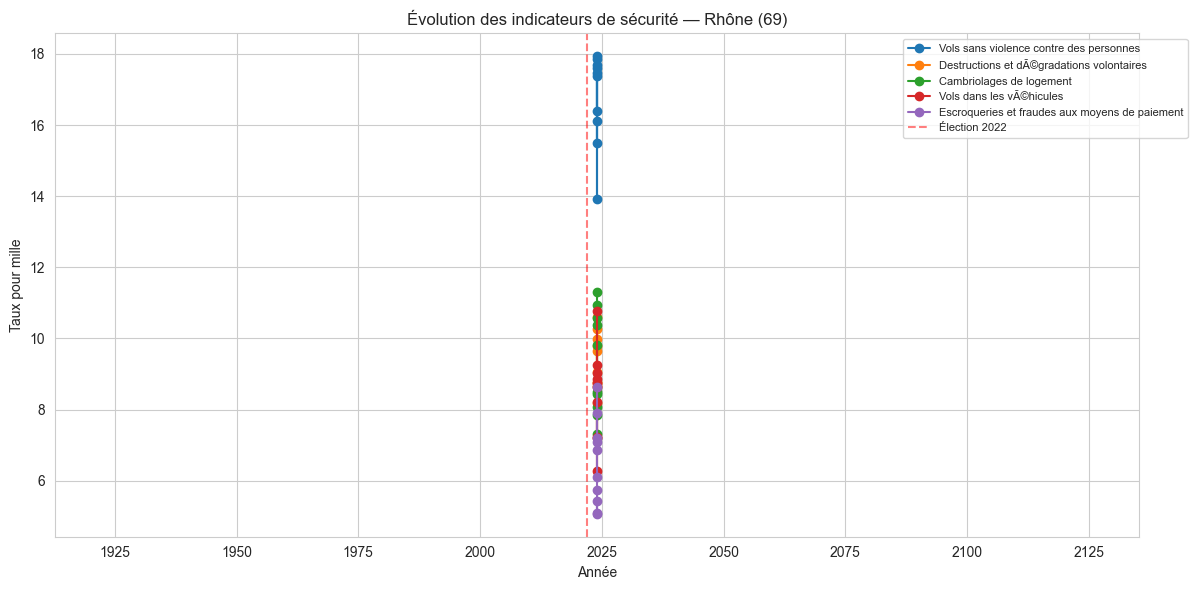

In [15]:
# ============================================================
# GRAPHIQUE 6 : Évolution sécurité dans le Rhône
# ============================================================
df_secu_evol = df_securite.copy()
df_secu_evol['annee'] = pd.to_numeric(df_secu_evol['annee'], errors='coerce')

top_indicateurs = (
    df_secu_evol.groupby('indicateur')['taux_pour_mille'].mean()
    .nlargest(5).index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
for indicateur in top_indicateurs:
    data = df_secu_evol[df_secu_evol['indicateur'] == indicateur].sort_values('annee')
    ax.plot(data['annee'], data['taux_pour_mille'], marker='o', label=indicateur)

ax.axvline(x=2022, color='red', linestyle='--', alpha=0.5, label='Élection 2022')
ax.set_xlabel('Année')
ax.set_ylabel('Taux pour mille')
ax.set_title('Évolution des indicateurs de sécurité — Rhône (69)')
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
# plt.savefig('graph_06_securite_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Export du dataset final

In [16]:
# ============================================================
# Sauvegarder le dataset complet pour le Notebook 3
# ============================================================
# df_final.to_csv('dataset_complet_rhone.csv', index=False, sep=';', encoding='utf-8-sig')

# print('Fichier exporté : dataset_complet_rhone.csv')
# print(f'  → {len(df_final)} communes')
# print(f'  → {len(df_final.columns)} colonnes')
# print(f'\nVariable cible (bloc_gagnant) :')
# print(df_final['bloc_gagnant'].value_counts().to_string())